# User Funnel Drop-off Analysis

## Load Dataset

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("../data/funnel_events_sample.csv")


In [35]:
df.head()

,user_id,step,timestamp
0,U072,visited_site,2026-07-20 04:01:00
1,U054,signup_started,2026-07-20 03:56:00
2,U170,visited_site,2026-07-20 03:50:00
3,U193,visited_site,2026-07-20 03:31:00
4,U190,visited_site,2026-07-20 04:01:00


## Data Cleaning

In [36]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    542 non-null    object
 1   step       542 non-null    object
 2   timestamp  542 non-null    object
dtypes: object(3)
memory usage: 12.8+ KB
None
       user_id          step            timestamp
count      542           542                  542
unique     200             5                   90
top       U072  visited_site  2026-07-20 03:54:00
freq         3           200                   18


In [37]:
# Data Cleaning
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Remove duplicate user-step combinations
df = df.drop_duplicates(subset=['user_id', 'step'])

# Funnel Order
funnel_steps = [
    'visited_site',
    'signup_started',
    'details_filled',
    'email_verified',
    'purchase_completed'
]

## Unique Users at Each Stage

In [38]:
user_counts = (
    df['step']
      .value_counts()
      .reindex(funnel_steps)
)
user_counts

,count
step,
visited_site,200
signup_started,150
details_filled,96
email_verified,52
purchase_completed,44


 ## Stage-wise Conversion Rate

In [39]:
# Conversion Rate
conversion_rate = (
    user_counts.div(user_counts.shift(1))
               .mul(100)
               .fillna(100)
               .round(2)
)

display(conversion_rate.to_frame(name="Conversion Rate (%)"))

,Conversion Rate (%)
step,
visited_site,100.00
signup_started,75.00
details_filled,64.00
email_verified,54.17
purchase_completed,84.62


## Stage-wise Drop-off Rate

In [40]:
# Drop-off
dropoff_rate = (
    (1 - user_counts.div(user_counts.shift(1)))
    .mul(100)
    .fillna(0)
    .round(2)
)


display(dropoff_rate.to_frame(name="Drop-off Rate (%)"))

,Drop-off Rate (%)
step,
visited_site,0.00
signup_started,25.00
details_filled,36.00
email_verified,45.83
purchase_completed,15.38


## Final Funnel Analysis Table

In [41]:
funnel = pd.DataFrame({
    "Stage": funnel_steps,
    "Users": user_counts.values,
    "Conversion Rate (%)": conversion_rate.values,
    "Drop-off Rate (%)": dropoff_rate.values
})

display(funnel)

,Stage,Users,Conversion Rate (%),Drop-off Rate (%)
0,visited_site,200,100.00,0.00
1,signup_started,150,75.00,25.00
2,details_filled,96,64.00,36.00
3,email_verified,52,54.17,45.83
4,purchase_completed,44,84.62,15.38


## Biggest Drop-off Stage

In [42]:
# Biggest Drop-off
largest_drop_stage = dropoff_rate.idxmax()
largest_drop_value = dropoff_rate.max()

print(f"Stage          : {largest_drop_stage.replace('_', ' ').title()}")
print(f"Drop-off Rate  : {largest_drop_value:.2f}%")

Stage          : Email Verified
Drop-off Rate  : 45.83%


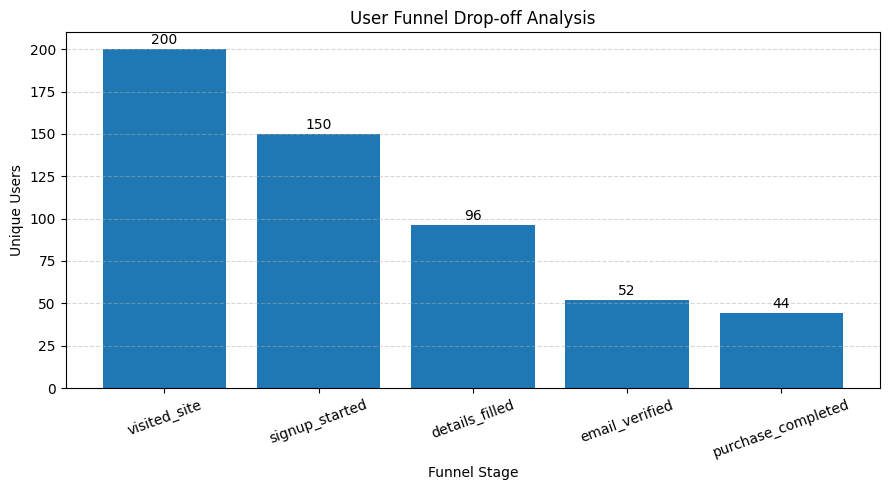

In [43]:
# Funnel Chart
plt.figure(figsize=(9,5))

plt.bar(
    funnel['Stage'],
    funnel['Users']
)

plt.title("User Funnel Drop-off Analysis")

plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, value in enumerate(funnel['Users']):
    plt.text(
        i,
        value + 3,
        str(value),
        ha='center',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../images/funnel_chart.png",
    dpi=300
)

plt.show()

In [44]:
print("="*60)
print("BUSINESS INSIGHT")
print("="*60)

print(
    f"The largest drop-off occurs between Details Filled and "
    f"Email Verified with a drop-off of {largest_drop_value:.2f}%."
)

print()

print(
    "Recommendation: Improve the email verification process by "
    "sending verification emails instantly, providing a "
    "'Resend Verification Email' option, and minimizing "
    "verification friction."
)

BUSINESS INSIGHT
The largest drop-off occurs between Details Filled and Email Verified with a drop-off of 45.83%.

Recommendation: Improve the email verification process by sending verification emails instantly, providing a 'Resend Verification Email' option, and minimizing verification friction.


In [45]:
# Export Results
funnel.to_csv(
    "../output/funnel_analysis_results.csv",
    index=False
)

print("\nAnalysis Complete.")
print("Generated:")
print("1. funnel_chart.png")
print("2. funnel_analysis_results.csv")


Analysis Complete.
Generated:
1. funnel_chart.png
2. funnel_analysis_results.csv


/content


['.config',
 'funnel_analysis_results.csv',
 'funnel_chart.png',
 'funnel_events_sample.csv',
 'sample_data']